Configuring unpretrained model: XLM-R_Untrained


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=134278304153232 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=278,045,955 params_trainable=278,045,955


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,1.047200,0.727509,0.700000,0.689831,0.700551,0.700000,0.145407,43.622093
2,0.696800,0.492738,0.786667,0.786389,0.793205,0.786667,0.094318,28.295273
3,0.493400,0.417467,0.843333,0.844449,0.847979,0.843333,0.079952,23.985670
4,0.378100,0.394729,0.836667,0.834272,0.840363,0.836667,0.076106,22.831863
5,0.313500,0.377248,0.863333,0.862551,0.868837,0.863333,0.067606,20.281651
6,0.260900,0.350207,0.880000,0.879906,0.886143,0.880000,0.062375,18.712482
7,0.201800,0.340023,0.870000,0.870207,0.871433,0.870000,0.062581,18.774448
8,0.186900,0.346352,0.880000,0.880374,0.881123,0.880000,0.063115,18.934631
9,0.187900,0.382510,0.856667,0.856080,0.861372,0.856667,0.069237,20.771250
10,0.151800,0.349247,0.890000,0.889529,0.889443,0.890000,0.062284,18.685221


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=20.21s tok/s=0.0 ex/s=0.00 peak_mem=5.23GiB lr=9.68e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.18s tok/s=447339.6 ex/s=3494.84
[EVALUATION_PERFORMANCE] accuracy=0.7000 cost=$0.01 accuracy_per_$=59.74
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.684361549497849e-06 id=134278304153232 hyperparams={'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.684361549497849e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.19s tok/s=437696.4 ex/s=3419.50
[EVALUATION_PERFORMANCE] accuracy=0.8767 cost=$0.25 accuracy_per_$=3.51

### XLM-ROBERTA-BASE EVALUATION METRICS ###
{'epoch': 10.0,
 'eval_accuracy': 0.8766666666666667,
 'eval_f1_macro': 0.8766143320249672,
 'eval_loss': 0.4245853126049042,
 'eval_mse': 0.07000621334515114,
 'eval_precision_macro': 0.8765906590659066,
 'eval_recall_macro': 0.8766666666666666,
 'eval_runtime': 0.2491,
 'eval_samples_per_second': 1204.191,
 'eval_sse': 21.001864003545343,
 'eval_steps_per_second': 20.07}


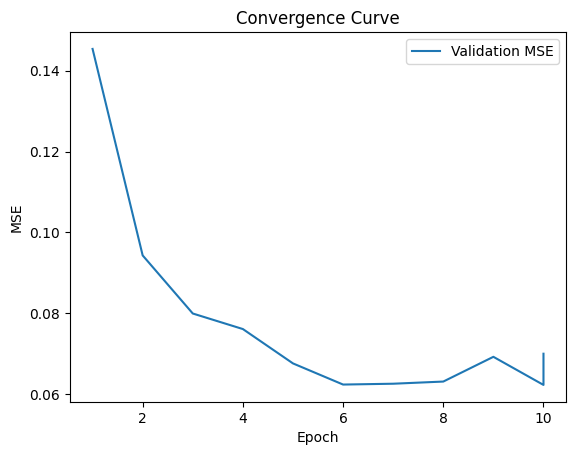

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    xlmru_context = context.setup_pipeline(XlmrUntrained, require_translation = False)
    xlmru_trainer = sentiment.train(xlmru_context)

